# Clustering Lab

 
Based of the amazing work you did in the Movie Industry you've been recruited to the NBA! You are working as the VP of Analytics that helps support a head scout, Mr. Rooney, for the worst team in the NBA probably the Wizards. Mr. Rooney just heard about Data Science and thinks it can solve all the team's problems!!! He wants you to figure out a way to find players that are high performing but maybe not highly paid that you can steal to get the team to the playoffs! 

In this document you will work through a similar process that we did in class with the NBA data files will be in the canvas assignment, merging them together.

Details: 

- Determine a way to use clustering to estimate based on performance if 
players are under or over paid, generally. 

- Then select players you believe would be best for your team and explain why. Do so in three categories: 
    * Examples that are not good choices (3 or 4) 
    * Several options that are good choices (3 or 4)
    * Several options that could work, assuming you can't get the players in the good category (3 or 4)

- You will decide the cutoffs for each category, so you should be able to explain why you chose them.

- Provide a well commented and clean report of your findings in a separate notebook that can be presented to Mr. Rooney, keeping in mind he doesn't understand...anything. Include a rationale for variables you included in the model, details on your approach and a overview of the results with supporting visualizations. 


Hints:

- Salary is the variable you are trying to understand 
- When interpreting you might want to use graphs that include variables that are the most correlated with Salary
- You'll need to scale the variables before performing the clustering
- Be specific about why you selected the players that you did, more detail is better
- Use good coding practices, comment heavily, indent, don't use for loops unless totally necessary and create modular sections that align with some outcome. If necessary create more than one script,list/load libraries at the top and don't include libraries that aren't used. 
- Be careful for non-traditional characters in the players names, certain graphs won't work when these characters are included.


In [2]:
# import libraries
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt

In [3]:
# Load in the Data
salary_data = pd.read_csv('2025_salaries.csv', header=1, encoding='latin-1')
stats = pd.read_csv('nba_2025.txt', sep=',', encoding='latin-1')

# Merge the Data
merged_data = pd.merge(salary_data, stats, on='Player')

# Drop variables that will not be needed or are duplicates
duplicates = merged_data[merged_data.duplicated(subset='Player', keep=False)] 
#many duplicates, let's keep the ones with the highest games played, keep this in mind for later
# salary is an object column and needs to be numeric
merged_data['Salary'] = merged_data['2025-26'].str.replace('$','').str.replace(',','').astype(float)
# Can't decide whether to use the numeric salary as a 
# colorbar or make it boolean, i tried the boolean and 
# my legend was kind of weird looking? -> I decided to keep it a colorbar
to_drop = ['Awards', 'Player-additional', '2025-26'] 
# awards column has all Nan values, 
# player-additional is not useful,
# 2025-26 can be dropped since we already converted it to
# numeric salary column
merged_data = merged_data.drop(columns=to_drop)
# fill missing values with 0
merged_data = merged_data.fillna(0)
# drop the duplicate rows, keeping the one with the highest number of games played
merged_data = merged_data.sort_values('G', ascending=False).drop_duplicates(subset='Player', keep='first')
merged_data.shape


(414, 33)

In [4]:
#Run the clustering algo with your best guess for K
from sklearn.cluster import KMeans
# select only numeric features
clust1 = merged_data[['G', 'FG%', '2P%', '3P%', 'TRB', 'MP', 'FT%','ORB','DRB','STL', 'TOV']]
# scale the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
clust1_scaled = scaler.fit_transform(clust1)
# run kmeans
kmeans_sample = KMeans(n_clusters=3, random_state=42, verbose=1)
kmeans_sample.fit(clust1_scaled)

Initialization complete
Iteration 0, inertia 4013.7717040052426.
Iteration 1, inertia 2753.507786368611.
Iteration 2, inertia 2647.985955617358.
Iteration 3, inertia 2632.1836484835603.
Iteration 4, inertia 2628.832538981945.
Iteration 5, inertia 2627.5115306095263.
Iteration 6, inertia 2627.4630357628753.
Converged at iteration 6: strict convergence.


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",1
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [6]:
#View the results- data is in too many dimensions to plot
print(kmeans_sample.cluster_centers_)
print(kmeans_sample.labels_)

# try visualizing a couple features in 3d
import cluster_utils as cu
# clusters with field goal percentage, three point percentage, and total rebounds
cu.visualize_clusters_3d(clust1, kmeans_sample.labels_, 'FG%', '3P%', 'TRB', show=True)
# looks relatively flat on the 3 point percentage, there's not
# much variance there so maybe try a different variable?

[[ 5.97405382e-01 -9.75159789e-02 -2.95943286e-02  3.14394849e-01
   2.70004976e-01  6.93049785e-01  2.83466585e-01  1.66853038e-03
   3.63390667e-01  6.72062068e-01  5.78864038e-01]
 [-8.69506084e-01 -2.87095356e-01 -1.95970135e-01 -1.37039981e-01
  -8.56073916e-01 -9.80686776e-01 -1.60344101e-01 -6.63947204e-01
  -8.67154210e-01 -8.76947867e-01 -8.01405147e-01]
 [ 6.07273342e-01  1.12978114e+00  6.54635559e-01 -5.98604832e-01
   1.60094180e+00  6.24217035e-01 -4.34349690e-01  1.89655476e+00
   1.33827792e+00  3.93231270e-01  4.70656927e-01]]
[2 2 0 0 2 0 0 0 0 2 0 0 0 0 2 0 0 0 0 2 2 0 2 0 0 0 0 0 0 0 0 0 2 0 0 0 0
 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 2 2 0 0 0 2 2 0 0 0 0 2 0 0 2 2 0 0 0 1
 2 0 0 0 2 0 0 0 0 0 0 0 2 2 0 0 2 0 0 0 0 2 2 0 0 0 0 2 0 0 0 0 0 0 0 0 2
 2 0 0 0 0 2 0 2 0 0 0 0 0 1 2 1 2 0 0 0 0 0 0 0 1 0 0 2 0 1 2 0 0 0 1 2 0
 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 2 1 0 0 0 0 0 2 0 2 0 1 0 1 0 2 1 0
 0 0 2 0 0 0 0 2 0 1 2 0 1 2 1 2 2 0 1 0 1 0 0 2 1 2 0 0 0 0 0 2 2 0 1 2 0


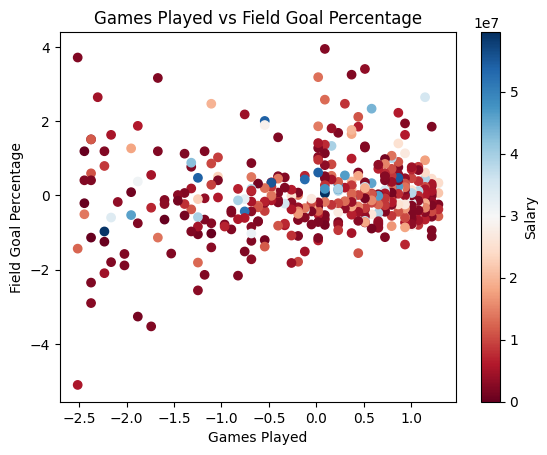

In [7]:
#Create a visualization of the results with 2 or 3 variables that you think will best
#differentiate the clusters

# scale features of interest and visualize a few in 2d
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features = merged_data[['G', 'FG%', '2P%', '3P%', 'TRB', 'MP', 'FT%','ORB','DRB','STL', 'TOV']]
features_scaled = scaler.fit_transform(features)

# try scatter plots in 2d with salary as color
# field goal percentage and games played
g = plt.scatter(features_scaled[:, 0], features_scaled[:, 1], c=merged_data['Salary'], cmap='RdBu')
plt.colorbar(g, label='Salary')
plt.title('Games Played vs Field Goal Percentage')
plt.xlabel('Games Played')
plt.ylabel('Field Goal Percentage')
plt.show()

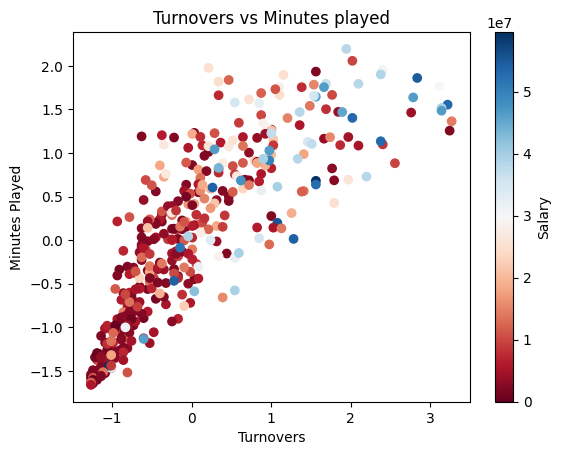

In [8]:
# continued from above...
# turnovers and minutes played
g = plt.scatter(features_scaled[:, 10], features_scaled[:, 5], c=merged_data['Salary'], cmap='RdBu')
plt.colorbar(g, label='Salary')
plt.title('Turnovers vs Minutes played')
plt.xlabel('Turnovers')
plt.ylabel('Minutes Played')
plt.show()

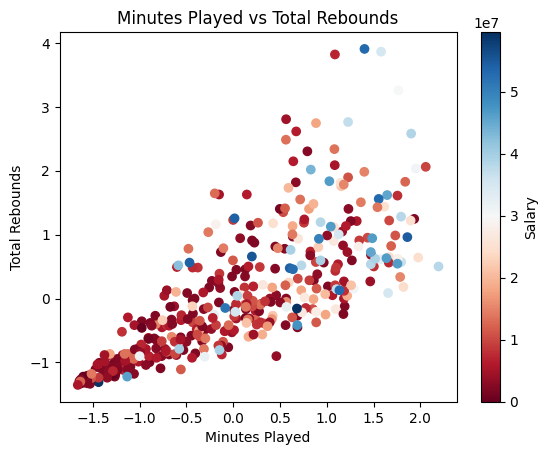

In [11]:
# continued from above...
# minutes played and total rebounds
g = plt.scatter(features_scaled[:, 5], features_scaled[:, 4], c=merged_data['Salary'], cmap='RdBu')
plt.colorbar(g, label='Salary')
plt.title('Minutes Played vs Total Rebounds')
plt.xlabel('Minutes Played')
plt.ylabel('Total Rebounds')
plt.show()

# After looking at the 3-var scatter plots with salary
# as the color var, i think I want my clustering
# variables to be minutes played, total rebounds,
# and turnovers

# in another notebook, I looked at individual scatterplots 
# of different variables vs. salary, and MP, TRB, and TOV all had high 
# variances. This also factored into my decision to keep these three variables.

In [12]:
# try a 3d scatter plot using salary as a color
import plotly.express as px
fig = px.scatter_3d(merged_data, 
                    x='MP', y='TRB', z='TOV',
                    color='Salary')
fig.show()
# this kind of shows a relationship? we want people that 
# have a lower salary, low turnovers, high minutes, and
# high total rebounds

In [ ]:
# Set up KMeans clustering with my variables of interest
cluster = features_scaled[:,[4,5,10]]
# I use features_scaled since I already scaled all the relevant variables.
# run kmeans
kmeans = KMeans(n_clusters=5, random_state=42, verbose=1) 
# using 5 clusters here to see what happens
kmeans.fit(cluster)
#Evaluate the quality of the clustering using total variance explained and silhouette scores
df = pd.DataFrame(cluster, columns=['TRB','MP','TOV'], index=merged_data['Player'])
# df.head() --> looks good

total_sum_squares = np.sum((df - np.mean(df))**2)
total_ss = np.sum(total_sum_squares)
within_ss = kmeans.inertia_
between_ss = total_ss - within_ss

var_ex = between_ss / total_ss
print(f"The total variance explained is {var_ex}.") # this is pretty good!
# Evaluate the clustering with silhouette scores
# convert cluster to a dataframe, with index as their name for identification

cu.calculate_silhouette_scores(df, random_state=42)
# honestly not great. better than nothing??

Initialization complete
Iteration 0, inertia 301.4544897678759.
Iteration 1, inertia 244.80476858640915.
Iteration 2, inertia 239.93585623382828.
Iteration 3, inertia 237.59185414809613.
Iteration 4, inertia 236.10582358177658.
Iteration 5, inertia 232.95731649807612.
Iteration 6, inertia 230.78374501704025.
Iteration 7, inertia 228.70828030857103.
Iteration 8, inertia 224.85711077527614.
Iteration 9, inertia 219.19086973703367.
Iteration 10, inertia 217.19204883686717.
Iteration 11, inertia 216.88667091888317.
Iteration 12, inertia 216.341774868035.
Iteration 13, inertia 216.04820884000765.
Iteration 14, inertia 216.00893076500367.
Converged at iteration 14: strict convergence.
The total variance explained is 0.8260797658896911.


([0.4869969275933768,
  0.43751337361418113,
  0.3810878381725725,
  0.40146433750171456,
  0.3782169409069926,
  0.3713628180778631,
  0.3470209436673146,
  0.34591735636274656,
  0.3127850355012104],
 [2, 3, 4, 5, 6, 7, 8, 9, 10],
 2)

In [14]:
#Determine the ideal number of clusters using the elbow method and the silhouette coefficient
# use elbow method
inertias = []
k_values = range(1, 10)
for k in k_values: 
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df)
    inertias.append(kmeans.inertia_)
print(inertias)

# based on the results of the elbow method and the silhouette
# scores, I think that 3 clusters is ideal. As you will see 
# in the plot below, the inertia slows its decrease, and 
# the silhouette value of 3 clusters is relatively high for
# my model at 0.43.


[1242.0000000000002, 514.8603191347489, 326.1383634647618, 272.0166503715005, 216.00893076500367, 191.63157365648524, 180.17606863838847, 150.5677776234935, 140.51924352670434]


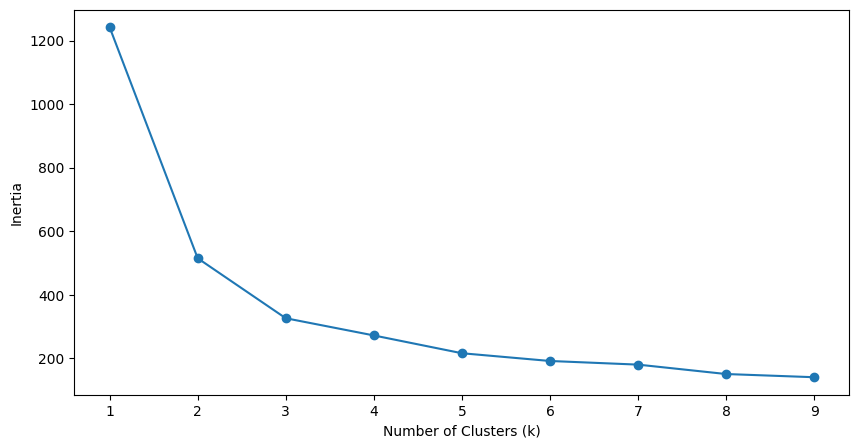

In [15]:
#Visualize the results of the elbow method
# visualize the results of the elbow method
plt.figure(figsize=(10,5))
plt.plot(k_values, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

In [17]:
#Use the recommended number of cluster (assuming it's different) to retrain your model and visualize the results
# let's re-train the kmeans model with the idea number of clusters (3)
# Set up kmeans clustering using my features of interest 
cluster_fin = features_scaled[:,[4,5,10]]
# run kmeans
kmeans_fin = KMeans(n_clusters=3, random_state=42, verbose=1) 
# using 5 clusters here to see what happens
kmeans_fin.fit(cluster_fin)

# visualize results: 3d scatter plot with salary as the color var,
# and cluster assignment as the shape of the point
df_fin = pd.DataFrame(cluster_fin, columns=['TRB','MP','TOV'], index=merged_data['Player'])
df_fin['cluster'] = kmeans_fin.labels_

fig = px.scatter_3d(df_fin, 
                    x='MP', y='TRB', z='TOV',
                    color=merged_data['Salary'],
                    symbol='cluster',
                    hover_name=df_fin.index)
fig.show()
# add in hover_name so it shows which player is each point
# It is really bothering me how squares and diamonds are used as different
# markers in this plot, but I don't know how/don't think it is possible
# to change it. 

Initialization complete
Iteration 0, inertia 439.5321025994734.
Iteration 1, inertia 352.10155241282496.
Iteration 2, inertia 341.4787328451923.
Iteration 3, inertia 338.48084306917997.
Iteration 4, inertia 335.2803905627083.
Iteration 5, inertia 331.3653154685938.
Iteration 6, inertia 329.522717522112.
Iteration 7, inertia 328.2374337499392.
Iteration 8, inertia 326.54631390320054.
Iteration 9, inertia 326.1527910767901.
Converged at iteration 9: center shift 7.829519646840385e-05 within tolerance 0.00010000000000000003.


In [18]:
#Once again evaluate the quality of the clustering using total variance explained and silhouette scores
# Total variance explained
total_sum_squares = np.sum((df - np.mean(df))**2)
total_ss = np.sum(total_sum_squares)
within_ss = kmeans_fin.inertia_
between_ss = total_ss - within_ss

var_ex = between_ss / total_ss
print(f"The total variance explained is {var_ex}.")

# Silhouette score
cu.calculate_silhouette_scores(df_fin, random_state=42)

The total variance explained is 0.7374087250686298.


([0.5570142919215949,
  0.5605855818753284,
  0.4422629415076127,
  0.3996620911859493,
  0.35624080864908475,
  0.37141372014231744,
  0.36882175366972,
  0.3713733956516603,
  0.3655362046409274],
 [2, 3, 4, 5, 6, 7, 8, 9, 10],
 3)

In [19]:
#Use the model to select players for Mr. Rooney to consider

# Here is a list of 4 target players for Mr. Rooney to consider:
# Donovan Clingan, Julian Champagnie, Peyton Pritchard, Mikal Bridges
# I based this off of relatively high rebounds and minutes played, 
# and relatively low turnovers, with a lower salary. All of these players are in cluster 2.
# 
# Here are some other attainable options if we can't get our target players:
# DeMar DeRozan, John Collins, Cooper Flagg, Saddiq Bey
# I based these off of players that also have relatively low salaries 
# and good stats. Cooper Flagg was kind of an out-there pick, but I think his name
# could bring a lot of attention to our team and bring up morale. 
#
# Here are some players that are NOT good choices: 
# Bradley Beal, Dillon Jones, Ja Morant, Kevin Durant
# I based these decisions based off two criteria:
# salary --> players like Kevin Durant and Bradley Beal are paid way too much to leave
# and Ja Morant is likely the same. 
# performance --> Dillon Jones and Bradley Beal seem to be poor performers
# anyways, and Ja Morant looks to not be the best either.

In [20]:
#Write up the results in a separate notebook with supporting visualizations and 
# an overview of how and why you made the choices you did. This should be at least 
# 500 words and should be written for a non-technical audience.